Based on https://github.com/XENON1T/CEvNS/blob/master/notebooks/B8_neutrino_spectrum.ipynb

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json as js
from tqdm import tqdm

import pickle

from scipy.interpolate import interp1d

In [2]:
params = {
    'xtick.direction' : 'in',
    'ytick.direction' : 'in',
    'font.family' : 'serif',
    'font.size' : 15,
    'xtick.labelsize' : 15,
    'ytick.labelsize' : 15,
    'xtick.major.size' : 8,
    'ytick.major.size' : 8,
    'xtick.major.width' : 1.5,
    'ytick.major.width' : 1.5,
    'axes.linewidth' : 1.5,
    'axes.labelsize' : 17
}

plt.rcParams.update(params)
# plt.rc('text', usetex=True)

In [3]:
""" IN SI UNIT """
""" Reduced Planck Constant in J·s """
HBAR = 1.054571800E-34
""" Speed of Light in m/s """
C = 2.99792458E8
""" Avogaro's Number in 1/mol """
A_V = 6.022140857E23
""" Charge of Electron in C """
CH_E = 1.6021766208E-19

""" keV in J """
KEV = 1e3 * CH_E
""" GeV in J """
GEV = 1e9 * CH_E

In [4]:
Xe124 = {
    'Type'		: 'Xe124',
    'MassNum'	: 124,
    'AtomicNum'	: 54,
    'Mass'		: 123.905893,
    'Spin'		: 0,
    'Fraction'	: 9.52E-4
}

Xe126 = {
    'Type'		: 'Xe126',
    'MassNum'	: 126,
    'AtomicNum'	: 54,
    'Mass'		: 125.904274,
    'Spin'		: 0,
    'Fraction'	: 8.90E-4
}

Xe128 = {
    'Type'		: 'Xe128',
    'MassNum'	: 128,
    'AtomicNum'	: 54,
    'Mass'		: 127.9035313,
    'Spin'		: 0,
    'Fraction'	: 0.019102
}

Xe129 = {
    'Type'		: 'Xe129',
    'MassNum'	: 129,
    'AtomicNum'	: 54,
    'Mass'		: 128.9047794,
    'Spin'		: 0.5,
    'Fraction'	: 0.264006
}

Xe130 = {
    'Type'		: 'Xe130',
    'MassNum'	: 130,
    'AtomicNum'	: 54,
    'Mass'		: 129.9035080,
    'Spin'		: 0,
    'Fraction'	: 0.040710
}

Xe131 = {
    'Type'		: 'Xe131',
    'MassNum'	: 131,
    'AtomicNum'	: 54,
    'Mass'		: 130.9050824,
    'Spin'		: 1.5,
    'Fraction'	: 0.212324
}

Xe132 = {
    'Type'		: 'Xe132',
    'MassNum'	: 132,
    'AtomicNum'	: 54,
    'Mass'		: 131.9041535,
    'Spin'		: 0,
    'Fraction'	: 0.269086
}

Xe134 = {
    'Type'		: 'Xe134',
    'MassNum'	: 134,
    'AtomicNum'	: 54,
    'Mass'		: 133.9053945,
    'Spin'		: 0,
    'Fraction'	: 0.104357
}

Xe136 = {
    'Type'		: 'Xe136',
    'MassNum'	: 136,
    'AtomicNum'	: 54,
    'Mass'		: 135.907219,
    'Spin'		: 0,
    'Fraction'	: 0.088573
}

ATOM_TABLE = {
    'Xe124'	: Xe124,
    'Xe126'	: Xe126,
    'Xe128'	: Xe128,
    'Xe129'	: Xe129,
    'Xe130'	: Xe130,
    'Xe131'	: Xe131,
    'Xe132'	: Xe132,
    'Xe134'	: Xe134,
    'Xe136'	: Xe136
}

In [5]:
GeV = 1.0
MeV = GeV / 1e3
keV = GeV / 1e6
eV = GeV / 1e9

# GeV ^ -1
m = 1.0 / (HBAR * C / GEV) / GeV
cm = m / 1e2
km = m * 1e3
mm = m / 1e3
um = m / 1e6
nm = m / 1e9
pm = m / 1e12
fm = m / 1e15

# GeV
kg = 1.0 * C**2 / GEV * GeV
ton = kg * 1e3
g = kg * 1e-3

# GeV ^ -1
sec = 1.0 * C * m
dy = 24.0 * 3600.0 * sec
yr = 365.0 * dy

# Fermi's const
Gf = 1.1663787e-5 / GeV**2

# Neutron mass
mn = 0.9314940954 * GeV

# Mixing angle
sin2the = 0.2223

# Standard model CEvNS spectrum

In [6]:
from scipy.special import spherical_jn
from scipy.integrate import quad

class TARGET(object):
    def __init__(self, atom, pure = False):
        super(TARGET, self).__init__()
        self.target = atom
        self.spin = atom["Spin"]
        self.abund = 1 if pure else atom["Fraction"]
        self.A = atom["MassNum"]
        self.Z = atom["AtomicNum"]
        self.N = self.A - self.Z
        self.mass = atom["Mass"] * mn
        self.Qw = self.N - (1 - 4.0 * sin2the) * self.Z
    
    def TransMoment(self, Er):
        return np.sqrt(2 * self.mass * Er)
    
    def MinNeutrinoEnergy(self, Er):
        return (Er + np.sqrt(Er**2 + 2 * self.mass * Er)) / 2.0
    
    def MaxRecoilEnergy(self, Ev):
        return 2 * Ev**2 / (self.mass + 2 * Ev)
    
    def FormFactor(self, q):
        if q == 0:
            return 1.0
        a = 0.52 * fm
        c = (1.23 * self.A**(1.0/3.0) - 0.6) * fm
        s = 0.9 * fm
        rn = np.sqrt(c**2 + 7.0 / 3.0 * np.pi**2 * a**2 - 5 * s**2)
        qrn = q * rn
        return (3 * spherical_jn(1, qrn) / qrn)**2 * np.exp(- (q * s)**2)

    #cross-section as given in equation 2 page 9 of CEvNS paper
    def dXsecdErecoil(self, Er, Ev):
        if Er > self.MaxRecoilEnergy(Ev):
            return 0
        q = self.TransMoment(Er)
        return Gf**2 / 4.0 / np.pi * self.Qw**2 * self.mass * (1 - self.mass * Er / 2 / Ev**2) * self.FormFactor(q)
    
    def Integrator(self, func, xmin, xmax):
        result, foo = quad(func, xmin, xmax)
        return result
    
    #modified by Riya
    #Assuming mono-energetic neutrinos
    #it is returning events/(ton*keV*Fluence) where fluence is flux integrated over time and so units of cm^(-2)
    def dRatedErecoil(self, Er, Ev):
        if Er > self.MaxRecoilEnergy(Ev):
            #print(".")
            return 0
        # f(_ev)=F*delta(_ev), so no-integration
        return self.dXsecdErecoil(Er, Ev) * self.abund / self.mass * (cm**(-2))

In [7]:
NaturalXe = [TARGET(ATOM_TABLE["Xe124"], pure = False),
          TARGET(ATOM_TABLE["Xe126"], pure = False),
          TARGET(ATOM_TABLE["Xe128"], pure = False),
          TARGET(ATOM_TABLE["Xe129"], pure = False),
          TARGET(ATOM_TABLE["Xe130"], pure = False),
          TARGET(ATOM_TABLE["Xe131"], pure = False),
          TARGET(ATOM_TABLE["Xe132"], pure = False),
          TARGET(ATOM_TABLE["Xe134"], pure = False),
          TARGET(ATOM_TABLE["Xe136"], pure = False)]

Number of target atoms:

In [8]:
N_T = sum([xe.abund/xe.mass for xe in NaturalXe]) * ton
N_T

4.588020143230578e+27

Checking effect of non-standard interactions

In [11]:
er = np.linspace(0.2, 100, 40)*keV
def EpsToMultiplier(eps_e_u, eps_e_d):
    smi = 0
    nsi = 0
    
    Qn_sm = -1
    Qn_ns = Qn_sm + 2 * eps_e_u + 4 * eps_e_d
    Qp_sm = 1 - 4.0 * sin2the
    Qp_ns = Qp_sm + 4 * eps_e_u + 2 * eps_e_d
    
    for xe in NaturalXe:
        smi += (xe.N * Qn_sm + xe.Z * Qp_sm) ** 2 * xe.abund
        nsi += (xe.N * Qn_ns + xe.Z * Qp_ns) ** 2 * xe.abund
        
    return nsi / smi

eps_e_d, eps_e_u = np.meshgrid(np.linspace(-1, 1, 30), np.linspace(-1, 1, 30))
eps_e_d = eps_e_d.ravel()
eps_e_u = eps_e_u.ravel()
multiplier = np.zeros_like(eps_e_d)

for i in tqdm(range(len(eps_e_d))):
    #print(i, EpsToMultiplier(eps_e_u[i], eps_e_d[i]))
    multiplier[i] = (5+EpsToMultiplier(eps_e_u[i], eps_e_d[i]))/6

multiplier = multiplier.reshape((30,30))
eps_e_d = eps_e_d.reshape((30,30))
eps_e_u = eps_e_u.reshape((30,30))

100%|██████████| 900/900 [00:00<00:00, 26448.77it/s]


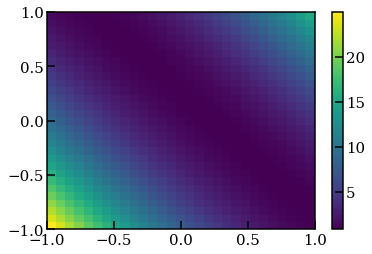

In [12]:
fig, ax = plt.subplots()
plt.pcolor(eps_e_d, eps_e_u, multiplier)
#plt.contour(eps_e_d, eps_e_u, multiplier, levels=[0,2])
#plt.plot(cf_x, cf_y1)
#plt.plot(cf_x, cf_y2)
plt.colorbar()
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.show()


In [13]:
#contour lines of xenon1t for these terms
cf_x = np.linspace(-1, 1, 30)
xenon1t_low_x1 = -1
xenon1t_low_y1 = 0.88
xenon1t_low_x2 = 0.75
xenon1t_low_y2 = -0.997

cf_slope1 = (xenon1t_low_y1 - xenon1t_low_y2)/(xenon1t_low_x1 - xenon1t_low_x2)
cf_y1 = cf_slope1*(cf_x-xenon1t_low_x1)+xenon1t_low_y1

xenon1t_high_x1 = -0.33
xenon1t_high_y1 = 0.997
xenon1t_high_x2 = 1
xenon1t_high_y2 = -0.5

cf_slope2 = (xenon1t_high_y1 - xenon1t_high_y2)/(xenon1t_high_x1 - xenon1t_high_x2)
cf_y2 = cf_slope2*(cf_x-xenon1t_high_x1)+xenon1t_high_y1

In [14]:
eps_e_u = []
eps_e_d = []
for i in range(0,30):
    eps_e_u.append(np.linspace(max(-1,cf_y1[i]), min(cf_y2[i],1), 10))
    eps_e_d.append(cf_x[i])

In [15]:
multiplier = np.zeros_like(eps_e_u)
eps_e_d_plot = []
for i in tqdm(range(len(eps_e_d))):
    for j in range(0, np.shape(eps_e_u)[1]):
        #print(i, EpsToMultiplier(eps_e_u[i], eps_e_d[i]))
        multiplier[i][j] = (5+EpsToMultiplier(eps_e_d[i], eps_e_u[i][j]))/6
    eps_e_d_plot.append(np.zeros(10) + eps_e_d[i])

100%|██████████| 30/30 [00:00<00:00, 1759.11it/s]


In [85]:
modification_low = np.min(multiplier)

In [84]:
modification_up = np.max(multiplier)

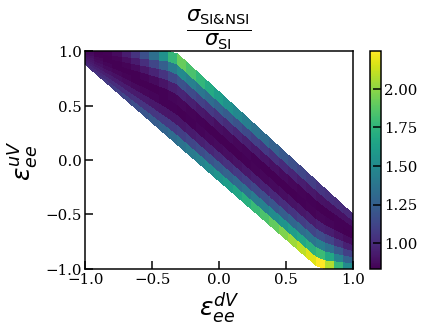

In [18]:
plt.pcolor(eps_e_d_plot, eps_e_u, multiplier)
plt.colorbar()

plt.xlabel(r'$\epsilon_{ee}^{dV}$', fontsize=25)
plt.ylabel(r'$\epsilon_{ee}^{uV}$', fontsize=25)
plt.title(r"$\frac{\sigma_\mathrm{SI&NSI}}{\sigma_\mathrm{SI}}$", fontsize=30)
plt.show()

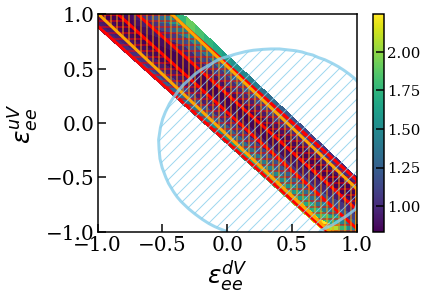

In [291]:
'''
# Data from COHERENT arxiv: 2003.10630
X = np.linspace(-1, 1, 50)
x, y = 0, 1

data = np.array([[-0.9639934533551555, 0.9699248120300752], [0.6628477905073649, -0.853383458646616]])
CsI_2017_lower = (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * X + data[0, y] - (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * data[0, x]

data = np.array([[-0.4108019639934535, 0.9849624060150377], [0.9410801963993451, -0.5375939849624058]])
CsI_2017_upper = (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * X + data[0, y] - (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * data[0, x]

data = np.array([[-0.9770867430441899, 0.868421052631579], [0.7086743044189852, -0.9323308270676689]])
CNNS_2020_1_lower = (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * X + data[0, y] - (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * data[0, x]

data = np.array([[-0.8232405891980361, 0.9812030075187971], [0.9083469721767594, -0.8721804511278193]])
CNNS_2020_1_upper = (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * X + data[0, y] - (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * data[0, x]

data = np.array([[-0.6497545008183307, 0.9548872180451129], [0.9443535188216035, -0.7368421052631575]])
CNNS_2020_2_lower = (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * X + data[0, y] - (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * data[0, x]

data = np.array([[-0.39770867430441903, 0.9661654135338347], [0.9705400981996726, -0.4924812030075185]])
CNNS_2020_2_upper = (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * X + data[0, y] - (data[0, y] - data[1, y]) / (data[0, x] - data[1, x]) * data[0, x]

data = np.array([[0.8994800693240901, 0.48707753479125215], [0.5251299826689775, 0.6660039761431408], [0.143847487001733, 0.6580516898608346], [-0.2079722703639515, 0.4850894632206757], [-0.4974003466204505, 0.03777335984095398], [-0.5181975736568458, -0.3280318091451293], [-0.3552859618717503, -0.7216699801192845], [-0.2512998266897746, -0.8330019880715707], [-0.09532062391681118, -0.9522862823061633], [0.7227036395147315, -0.9880715705765408], [0.8128249566724435, -0.9363817097415508], [0.9272097053726172, -0.848906560636183], [-0.37954939341421134, 0.2922465208747511], [-0.005199306759098743, -0.9960238568588471], [0.2755632582322358, 0.6779324055666001], [0.7053726169844019, 0.6023856858846914], [-0.0121317157712304, 0.6063618290258446], [-0.5285961871750432, -0.15308151093439393], [-0.4731369150779896, -0.4990059642147118], [-0.44540727902946275, 0.17693836978131183], [-0.41421143847486996, -0.6302186878727636], [-0.28249566724436725, 0.41153081510934353], [-0.11611785095320615, 0.5506958250497014], [0.0641247833622185, 0.6341948310139162], [0.40381282495667237, 0.6819085487077531], [0.8093587521663781, 0.5506958250497014], [0.6187175043327557, 0.6381709741550692], [0.9826689774696709, 0.41153081510934353], [0.9410745233968805, 0.4512922465208744], [0.9896013864818025, -0.79324055666004], [0.20277296360485275, 0.6699801192842939], [0.33795493934142096, 0.6819085487077532], [0.4627383015597919, 0.6739562624254469], [0.5771230502599654, 0.6540755467196815], [0.753899480069324, 0.5825049701789262], [0.6603119584055461, 0.62624254473161], [0.8578856152513001, 0.5188866799204768], [-0.2512998266897746, 0.4473161033797213], [-0.16117850953206214, 0.5188866799204768], [-0.06412478336221827, 0.5864811133200791], [-0.33448873483535535, 0.35586481113320045], [-0.4176776429809359, 0.2286282306163019], [-0.47660311958405543, 0.10139165009940321], [-0.5147313691507799, -0.04174950298210778], [-0.5251299826689774, -0.24055666003976173], [-0.5008665511265165, -0.4115308151093442], [-0.4523396880415944, -0.5546719681908552], [-0.3864818024263431, -0.6779324055666005], [-0.2998266897746966, -0.7852882703777337], [-0.19237435008665504, -0.8846918489065605], [-0.14038128249566717, -0.9244532803180916], [-0.05719237435008662, -0.9721669980119283], [0.11611785095320615, -1.0834990059642151], [0.36568457538994803, -1.1232604373757455], [0.653379549393414, -1.0994035785288272], [1.1698440207972274, -0.17296222664015937], [1.1837088388214903, 0.15308151093439337]])
CHARM_contour = np.array(sorted(data, key=lambda row: np.angle(row[0] + 1j * row[1])))

#plt.figure(figsize=(8, 7))
plt.gcf().subplots_adjust(left=0.15)

patch_cnn_style = {"edgecolor" : "red", "alpha" : 1, "hatch" : "--", "facecolor" : "None", "linewidth" : 3}
patch_csi_style = {"edgecolor" : "orange", "alpha" : 1, "hatch" : "||", "facecolor" : "None", "linewidth" : 3}
patch_xenon_style = {"edgecolor" : "green", "alpha" : 0.4, "facecolor" : "green", "linewidth" : 3}
patch_charm_style = {"edgecolor" : "skyblue", "alpha" : 0.8, "hatch" : '//', "facecolor" : "None", "linewidth" : 3}


# XENON1T
plt.pcolor(eps_e_d_plot, eps_e_u, multiplier)
plt.colorbar()

# From COHERENT paper
plt.fill(CHARM_contour[:, 0], CHARM_contour[:, 1], **patch_charm_style)
plt.fill_between(X, CNNS_2020_1_lower, CNNS_2020_1_upper, **patch_cnn_style)
plt.fill_between(X, CNNS_2020_2_lower, CNNS_2020_2_upper, **patch_cnn_style)
plt.fill_between(X, CsI_2017_lower, CsI_2017_upper, **patch_csi_style)





#plt.legend([plt.Rectangle((0,0), 1, 1, **style) for style in [patch_xenon_style, patch_csi_style, patch_cnn_style, patch_charm_style]],\
#           ["XENON1T", "CsI[Na] 2017", "CENNS-10 2020", "CHARM"],\
#           loc="lower left", fontsize=18)
plt.xticks([-1, -0.5, 0, 0.5, 1], fontsize=20)
plt.yticks([-1, -0.5, 0, 0.5, 1], fontsize=20)
plt.xlabel(r'$\epsilon_{ee}^{dV}$', fontsize=25)
plt.ylabel(r'$\epsilon_{ee}^{uV}$', fontsize=25)
plt.xlim(-1, 1)
plt.ylim(-1, 1)
# plt.savefig("constraint.png", dpi=500)
plt.show()
'''

Non-standard interactions can either cause cross-section to increase or decrease implying that rate and hence the limits can either increase or decrease.

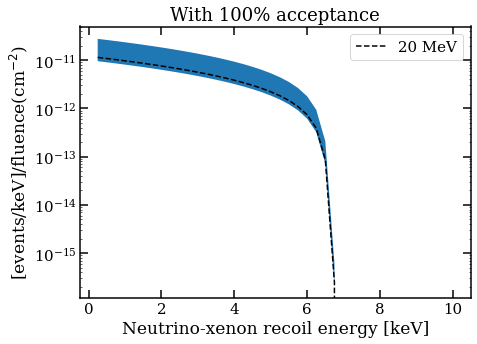

In [86]:
er = np.linspace(0.25, 10, 40)*keV
tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) for x in er])
tot_rate_low = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) for x in er])*modification_low
tot_rate_up = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) for x in er])*modification_up

fig, ax = plt.subplots(1, 1, figsize=(7,5))

ax.semilogy(er / keV, tot_rate * ton / (keV**(-1)), 'k--', label="20 MeV")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)))
ax.legend()
ax.set_title("With 100% acceptance")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/keV]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()



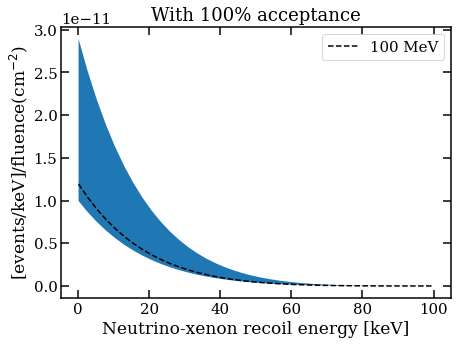

In [87]:
er = np.linspace(0.2, 100, 40)*keV
tot_rate = np.array([sum([xe.dRatedErecoil(x, 100*MeV) for xe in NaturalXe]) for x in er])
tot_rate_low = np.array([sum([xe.dRatedErecoil(x, 100*MeV) for xe in NaturalXe]) for x in er])*modification_low
tot_rate_up = np.array([sum([xe.dRatedErecoil(x, 100*MeV) for xe in NaturalXe]) for x in er])*modification_up

fig, ax = plt.subplots(1, 1, figsize=(7,5))

ax.plot(er / keV, tot_rate * ton / (keV**(-1)), 'k--', label="100 MeV")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)))

ax.legend()
ax.set_title("With 100% acceptance")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/keV]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

#  Acceptance

s2only_efficiency.csv is created using https://github.com/XENON1T/s2only/blob/master/analyses/total_efficiency.ipynb

where 'Energy' = d['es'] & 'Efficiency' = d['efficiency_nounc']

This efficiency includes reduction in fiducial target mass from 2.004 tonne.

In [19]:
acc_data = pd.read_csv('s2only_efficiency.csv')
accept = acc_data['Efficiency']*0.7 #because 30% of data is used for training
energy_S2only = acc_data['Energy'] * keV
accept_S2only = interp1d(energy_S2only, accept, bounds_error=False, fill_value=0, kind='linear')

In [20]:
acc_data = pd.read_csv('NR_acceptance_NSI_UL_200811.csv').drop(columns='Unnamed: 0')
accept = acc_data['acceptance']
energy_2fold = acc_data['energy'] * keV
accept_2fold = interp1d(energy_2fold, accept, bounds_error=False, fill_value=0, kind='linear')

In [91]:
er = np.linspace(0.225, 99.975, 1996)*keV

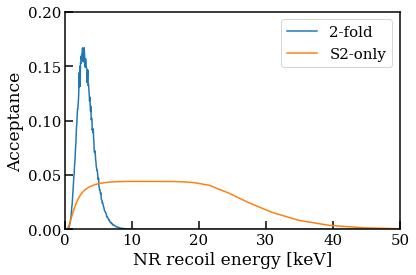

In [22]:
plt.plot(er / keV, accept_2fold(er), label="2-fold")
plt.plot(er / keV, accept_S2only(er), label="S2-only")
plt.xlim(0, 50)
plt.ylim(0, 0.2)
plt.xlabel('NR recoil energy [keV]')
plt.ylabel('Acceptance')
plt.legend()
plt.show()

Acceptance for 3-fold is available at https://github.com/XENON1T/SR1Results/tree/master/Calibration/TemplateFiles/180420/run_combined_source_combined/acceptances

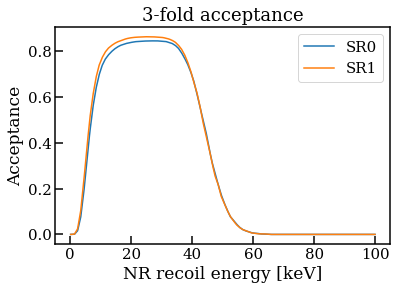

In [58]:
acceptanceFileNames = [
    'ERNRFitRunCombo_180420_acceptance_percentiles_wimp_sr0', # SR0 WIMPs
    'ERNRFitRunCombo_180420_acceptance_percentiles_wimp_sr1'  # SR1 WIMPs
]
percentiles = [pickle.load(open(af + '.pkl', 'rb')) for af in acceptanceFileNames]

energyEdges = percentiles[0]['energy_edges']* keV
energy_3fold = (energyEdges[1:] + energyEdges[:-1]) / 2.

accept = percentiles[0]['energy']['totalcombacc'].T[1]
accept_3fold_SR0 = interp1d(energy_3fold, accept, bounds_error=False, fill_value=0, kind='linear')

accept = percentiles[1]['energy']['totalcombacc'].T[1]
accept_3fold_SR1 = interp1d(energy_3fold, accept, bounds_error=False, fill_value=0, kind='linear')

plt.plot(er / keV, accept_3fold_SR0(er), label="SR0")
plt.plot(er / keV, accept_3fold_SR1(er), label="SR1")

plt.xlabel('NR recoil energy [keV]')
plt.ylabel('Acceptance')
plt.title("3-fold acceptance")
plt.legend()
plt.show()

# Events in 1 tonne detector at fixed Energy

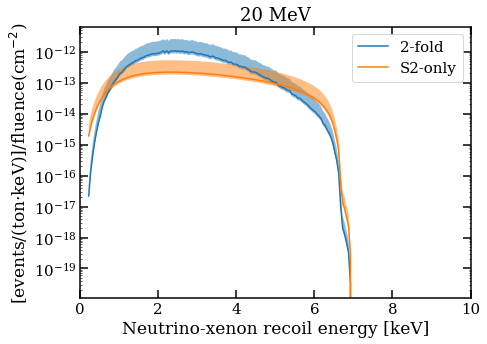

In [95]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))


tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_2fold(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="2-fold")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)

tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_S2only(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="S2-only")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)


ax.legend()
ax.set_title(r"20 MeV")
#ax.set_ylim([1e-2, 1e2])
ax.set_xlim([0, 10])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/(ton$\cdot$keV)]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

The reason we see sharp decrease around 6.5 keV is because that corresponds to the maximum recoil energy for a neutrino energy of 20 MeV.

In [54]:
er[125:136]/keV

array([6.475, 6.525, 6.575, 6.625, 6.675, 6.725, 6.775, 6.825, 6.875,
       6.925, 6.975])

In [53]:
np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_2fold(x) for x in er[125:136]])/(keV**(-1) * ton**(-1))

array([1.12986795e-15, 5.66130793e-16, 3.04803560e-16, 1.17604744e-16,
       1.00196992e-17, 2.05855082e-18, 1.27842832e-18, 6.73273790e-19,
       3.38359911e-19, 3.27585469e-20, 0.00000000e+00])

In [56]:
for xe in NaturalXe:
    print(xe.MaxRecoilEnergy(20*MeV))

6.928950078165352e-06
6.819009718609852e-06
6.712457700158839e-06
6.660337077491573e-06
6.609147767302718e-06
6.558596770051807e-06
6.508936681086748e-06
6.411690598635367e-06
6.3172804173262805e-06


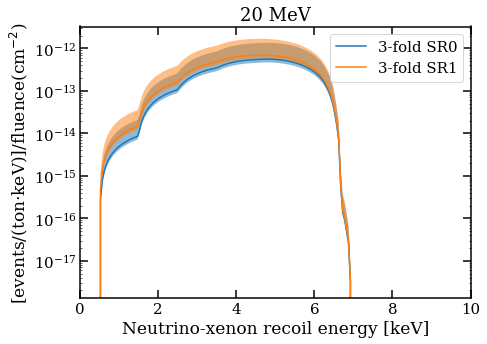

In [94]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))

tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_3fold_SR0(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="3-fold SR0")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)

tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_3fold_SR1(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="3-fold SR1")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)

ax.legend()
ax.set_title(r"20 MeV")
#ax.set_ylim([1e-2, 1e2])
ax.set_xlim([0, 10])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/(ton$\cdot$keV)]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

For 3-fold data we know acceptance at an interval of 1 keV but we interpolate for energies in between. This interpolation introduces kinks in acceptance (slope of change of acceptance with rate vary). This in turns propagates to kinks in spectrum of events at low energy.

In [73]:
energy_3fold/keV

array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
       11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5,
       22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5, 32.5,
       33.5, 34.5, 35.5, 36.5, 37.5, 38.5, 39.5, 40.5, 41.5, 42.5, 43.5,
       44.5, 45.5, 46.5, 47.5, 48.5, 49.5, 50.5, 51.5, 52.5, 53.5, 54.5,
       55.5, 56.5, 57.5, 58.5, 59.5, 60.5, 61.5, 62.5, 63.5, 64.5, 65.5,
       66.5, 67.5, 68.5, 69.5, 70.5, 71.5, 72.5, 73.5, 74.5, 75.5, 76.5,
       77.5, 78.5, 79.5, 80.5, 81.5, 82.5, 83.5, 84.5, 85.5, 86.5, 87.5,
       88.5, 89.5, 90.5, 91.5, 92.5, 93.5, 94.5, 95.5, 96.5, 97.5, 98.5,
       99.5])

In [78]:
er[0:90]/keV

array([0.225, 0.275, 0.325, 0.375, 0.425, 0.475, 0.525, 0.575, 0.625,
       0.675, 0.725, 0.775, 0.825, 0.875, 0.925, 0.975, 1.025, 1.075,
       1.125, 1.175, 1.225, 1.275, 1.325, 1.375, 1.425, 1.475, 1.525,
       1.575, 1.625, 1.675, 1.725, 1.775, 1.825, 1.875, 1.925, 1.975,
       2.025, 2.075, 2.125, 2.175, 2.225, 2.275, 2.325, 2.375, 2.425,
       2.475, 2.525, 2.575, 2.625, 2.675, 2.725, 2.775, 2.825, 2.875,
       2.925, 2.975, 3.025, 3.075, 3.125, 3.175, 3.225, 3.275, 3.325,
       3.375, 3.425, 3.475, 3.525, 3.575, 3.625, 3.675, 3.725, 3.775,
       3.825, 3.875, 3.925, 3.975, 4.025, 4.075, 4.125, 4.175, 4.225,
       4.275, 4.325, 4.375, 4.425, 4.475, 4.525, 4.575, 4.625, 4.675])

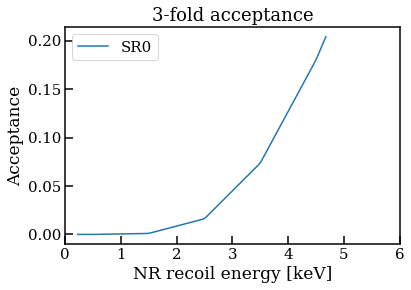

In [76]:
acceptance = np.array([accept_3fold_SR0(x) for x in er[0:90]])
plt.plot(er[0:90] / keV, acceptance, label="SR0")
#plt.plot(er / keV, accept_3fold_SR1(er), label="SR1")

plt.xlabel('NR recoil energy [keV]')
plt.ylabel('Acceptance')
plt.title("3-fold acceptance")
plt.xlim(0, 6)
plt.legend()
plt.show()

# Events in detector at fixed Energy with desired fiducial mass

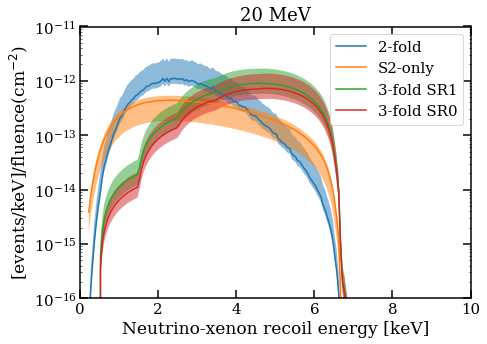

In [97]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))


tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_2fold(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate * 1.04 * ton/ keV**(-1), label="2-fold")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)

tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_S2only(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate * 2.004 * ton/ keV**(-1) , label="S2-only")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)

tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_3fold_SR1(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate * 1.3 * ton/ keV**(-1), label="3-fold SR1")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)
tot_rate = np.array([sum([xe.dRatedErecoil(x, 20*MeV) for xe in NaturalXe]) * accept_3fold_SR0(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate * 1.3 * ton/ keV**(-1), label="3-fold SR0")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)


ax.legend()
ax.set_title(r"20 MeV")
ax.set_ylim([1e-16, 1e-11])
ax.set_xlim([0, 10])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/keV]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

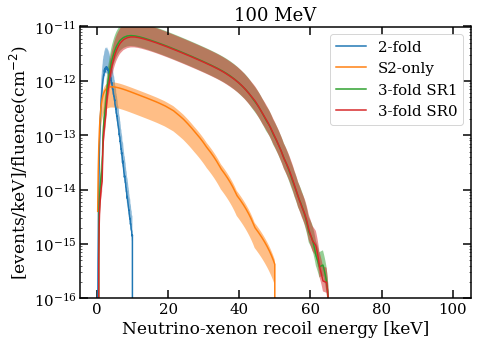

In [110]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))

tot_rate = np.array([sum([xe.dRatedErecoil(x, 100*MeV) for xe in NaturalXe]) * accept_2fold(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate * 1.04 * ton/ keV**(-1), label="2-fold")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)

tot_rate = np.array([sum([xe.dRatedErecoil(x, 100*MeV) for xe in NaturalXe]) * accept_S2only(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate * 2.004 * ton/ keV**(-1) , label="S2-only")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)

tot_rate = np.array([sum([xe.dRatedErecoil(x, 100*MeV) for xe in NaturalXe]) * accept_3fold_SR1(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate * 1.3 * ton/ keV**(-1), label="3-fold SR1")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)
tot_rate = np.array([sum([xe.dRatedErecoil(x, 100*MeV) for xe in NaturalXe]) * accept_3fold_SR0(x) for x in er])
tot_rate_low = tot_rate*modification_low
tot_rate_up = tot_rate*modification_up
ax.semilogy(er / keV, tot_rate * 1.3 * ton/ keV**(-1), label="3-fold SR0")
plt.fill_between(er / keV, tot_rate_low * ton / (keV**(-1)), tot_rate_up * ton / (keV**(-1)), alpha = 0.5)


ax.legend()
ax.set_title(r"100 MeV")
ax.set_ylim([1e-16, 1e-11])
#ax.set_xlim([0, 100])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/keV]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

We see that the different acceptance values of SR0 and SR1 produce results within uncertainty bounds. Therefore, even though there was one GW during SR0, to put limits on neutrino fluence using 3-fold analysis, we take acceptance as the acceptance of SR1.

Checking if integration (area under curve) gives reasonable values:

In [20]:
total_rate = 0
for i in range(0,np.shape(energy_S2only)[0]-1):
    er = (energy_S2only[i]+energy_S2only[i+1])/2
    delta_energy = energy_S2only[i+1] - energy_S2only[i]
    rate = sum([xe.dRatedErecoil(er, 20*MeV) for xe in NaturalXe]) * accept_S2only(er)
    total_rate = total_rate + rate * delta_energy * 2.004 * ton
total_rate

1.60943711289097e-12

In [21]:
total_rate = 0
for i in range(0,np.shape(energy_2fold)[0]-1):
    er = (energy_2fold[i]+energy_2fold[i+1])/2
    delta_energy = energy_2fold[i+1] - energy_2fold[i]
    rate = sum([xe.dRatedErecoil(er, 20*MeV) for xe in NaturalXe]) * accept_2fold(er)
    total_rate = total_rate + rate * delta_energy * 1.04 * ton
total_rate

2.591968631737068e-12

In [22]:
total_rate = 0

for i in range(0,np.shape(energy_3fold)[0]-1):
    er=((energy_3fold[i]+energy_3fold[i+1])/2)
    delta_energy = energy_3fold[i+1] - energy_3fold[i]
    rate = sum([xe.dRatedErecoil(er, 20*MeV) for xe in NaturalXe]) * accept_3fold_SR0(er)
    total_rate = total_rate + rate * delta_energy * 1.3 * ton
total_rate

2.1397461040474527e-12

In [23]:
total_rate = 0

for i in range(0,np.shape(energy_3fold)[0]-1):
    er=((energy_3fold[i]+energy_3fold[i+1])/2)
    delta_energy = energy_3fold[i+1] - energy_3fold[i]
    rate = sum([xe.dRatedErecoil(er, 20*MeV) for xe in NaturalXe]) * accept_3fold_SR1(er)
    total_rate = total_rate + rate * delta_energy * 1.3 * ton
total_rate

2.715130706614805e-12

# Events in detector for neutrino energies

In [24]:
np.linspace(5, 100, 96)

array([  5.,   6.,   7.,   8.,   9.,  10.,  11.,  12.,  13.,  14.,  15.,
        16.,  17.,  18.,  19.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,
        27.,  28.,  29.,  30.,  31.,  32.,  33.,  34.,  35.,  36.,  37.,
        38.,  39.,  40.,  41.,  42.,  43.,  44.,  45.,  46.,  47.,  48.,
        49.,  50.,  51.,  52.,  53.,  54.,  55.,  56.,  57.,  58.,  59.,
        60.,  61.,  62.,  63.,  64.,  65.,  66.,  67.,  68.,  69.,  70.,
        71.,  72.,  73.,  74.,  75.,  76.,  77.,  78.,  79.,  80.,  81.,
        82.,  83.,  84.,  85.,  86.,  87.,  88.,  89.,  90.,  91.,  92.,
        93.,  94.,  95.,  96.,  97.,  98.,  99., 100.])

In [80]:
Neutrino_Energy = np.linspace(5, 100, 96)*MeV

def calc_rate_Ev(energy, accept, fm):
    total_rate_Ev = []
    for Ev in Neutrino_Energy:
        total_rate = 0
        for i in range(0,np.shape(energy)[0]-1):
            er = (energy[i]+energy[i+1])/2
            delta_energy = energy[i+1] - energy[i]
            rate = sum([xe.dRatedErecoil(er, Ev) for xe in NaturalXe]) * accept(er)
            total_rate = total_rate + rate * delta_energy * fm * ton
        total_rate_Ev.append(total_rate)
    return(np.array(total_rate_Ev))

In [81]:
fm_3fold = 1.3
fm_2fold = 1.04 
fm_S2only = 2.004 #used in https://github.com/XENON1T/s2only/blob/master/analyses/total_efficiency.ipynb to calculate exposure

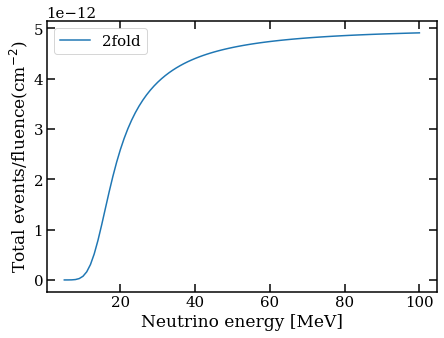

In [120]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
plt.plot(Neutrino_Energy/MeV, calc_rate_Ev(er, accept_2fold, fm_2fold), label="2fold")

#ax.legend()
#ax.set_title(r"(Total events/flux ")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Total events/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.legend()
plt.show()

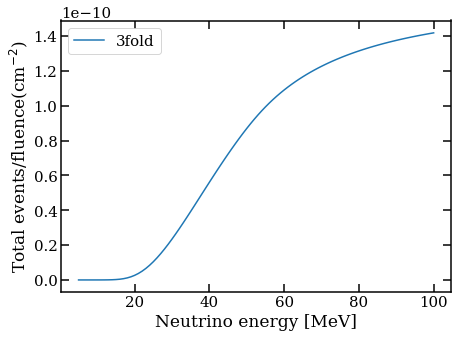

In [122]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
plt.plot(Neutrino_Energy/MeV, calc_rate_Ev(er, accept_3fold_SR1, fm_3fold), label="3fold")

#ax.legend()
#ax.set_title(r"(Total events/flux ")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Total events/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.legend()
plt.show()

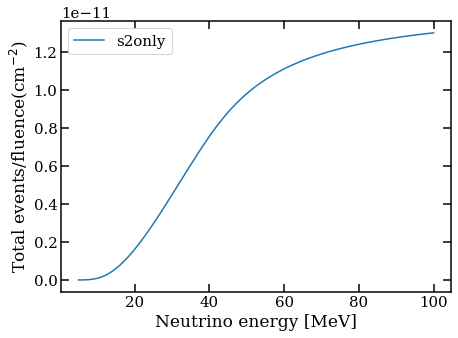

In [124]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
plt.plot(Neutrino_Energy/MeV, calc_rate_Ev(er, accept_S2only, fm_S2only), label="s2only")

#ax.legend()
#ax.set_title(r"(Total events/flux ")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Total events/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.legend()
plt.show()

In [99]:
rate_Ev_2fold = calc_rate_Ev(er, accept_2fold, fm_2fold)
rate_Ev_3fold = calc_rate_Ev(er, accept_3fold_SR1, fm_3fold)
rate_Ev_S2only = calc_rate_Ev(er, accept_S2only, fm_S2only)

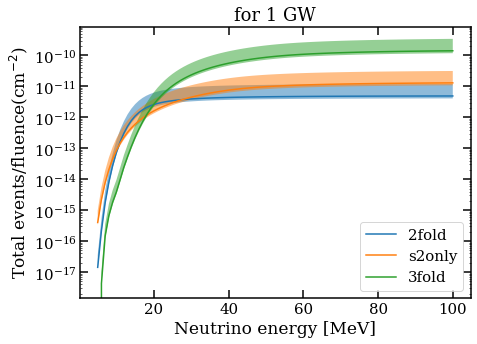

In [101]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
plt.plot(Neutrino_Energy/MeV, rate_Ev_2fold, label="2fold")
plt.fill_between(Neutrino_Energy/MeV, rate_Ev_2fold*modification_low, rate_Ev_2fold*modification_up, alpha = 0.5)

plt.plot(Neutrino_Energy/MeV, rate_Ev_S2only, label="s2only")
plt.fill_between(Neutrino_Energy/MeV, rate_Ev_S2only*modification_low, rate_Ev_S2only*modification_up, alpha = 0.5)

plt.plot(Neutrino_Energy/MeV, rate_Ev_3fold, label="3fold")
plt.fill_between(Neutrino_Energy/MeV, rate_Ev_3fold*modification_low, rate_Ev_3fold*modification_up, alpha = 0.5)

#ax.legend()
ax.set_title("for 1 GW")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
plt.yscale("log")

ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Total events/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.legend()
plt.show()

# Set constraints

We have only one observation point for neutron star mergers - GW170817

In [106]:
upper_lim_fluence_2_fold = 2.3/(rate_Ev_2fold)
upper_lim_fluence_2_fold_low = 2.3/(rate_Ev_2fold*modification_low)
upper_lim_fluence_2_fold_up = 2.3/(rate_Ev_2fold*modification_up)

upper_lim_fluence_3_fold = 2.3/(rate_Ev_3fold)
upper_lim_fluence_3_fold_low = 2.3/(rate_Ev_3fold*modification_low)
upper_lim_fluence_3_fold_up = 2.3/(rate_Ev_3fold*modification_up)

upper_lim_fluence_S2only = 2.3/(rate_Ev_S2only)
upper_lim_fluence_S2only_low = 2.3/(rate_Ev_S2only*modification_low)
upper_lim_fluence_S2only_up = 2.3/(rate_Ev_S2only*modification_up)

<ipython-input-106-50f37f936a05>:5: RuntimeWarning: divide by zero encountered in true_divide
  upper_lim_fluence_3_fold = 2.3/(rate_Ev_3fold)
<ipython-input-106-50f37f936a05>:6: RuntimeWarning: divide by zero encountered in true_divide
  upper_lim_fluence_3_fold_low = 2.3/(rate_Ev_3fold*modification_low)
<ipython-input-106-50f37f936a05>:7: RuntimeWarning: divide by zero encountered in true_divide
  upper_lim_fluence_3_fold_up = 2.3/(rate_Ev_3fold*modification_up)


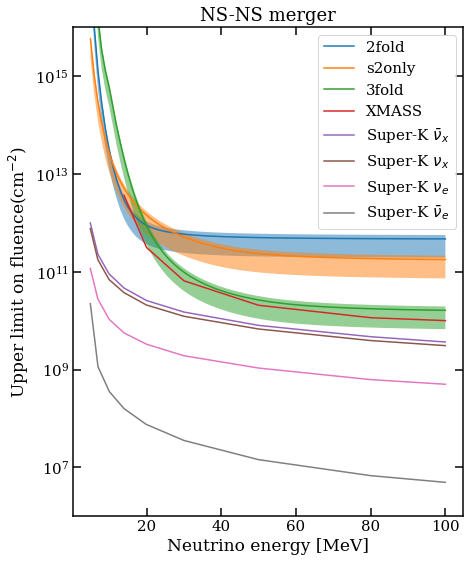

In [107]:
Anti_neutrinio_x = pd.read_csv('Anti_neutrino_x.csv')
neutrinio_x = pd.read_csv('neutrino_x.csv')
Anti_neutrinio_e = pd.read_csv('anti_neutrino_e.csv')
neutrinio_e = pd.read_csv('neutrino_e.csv')
XMASS_neutrinio = pd.read_csv('XMASS_neutrino.csv')

fig, ax = plt.subplots(1, 1, figsize=(7,9))
plt.plot(Neutrino_Energy/MeV, upper_lim_fluence_2_fold, label="2fold")
plt.fill_between(Neutrino_Energy/MeV, upper_lim_fluence_2_fold_low, upper_lim_fluence_2_fold_up, alpha = 0.5)
plt.plot(Neutrino_Energy/MeV, upper_lim_fluence_S2only, label="s2only")
plt.fill_between(Neutrino_Energy/MeV, upper_lim_fluence_S2only_low, upper_lim_fluence_S2only_up, alpha = 0.5)
plt.plot(Neutrino_Energy/MeV, upper_lim_fluence_3_fold, label="3fold")
plt.fill_between(Neutrino_Energy/MeV, upper_lim_fluence_3_fold_low, upper_lim_fluence_3_fold_up, alpha = 0.5)

plt.plot(XMASS_neutrinio['Energy'], XMASS_neutrinio['fluence'], label="XMASS")
plt.plot(Anti_neutrinio_x['Energy'], Anti_neutrinio_x['fluence'], label=r"Super-K $\bar{\nu}_x$")
plt.plot(neutrinio_x['Energy'], neutrinio_x['fluence'], label=r"Super-K ${\nu}_x$")
plt.plot(neutrinio_e['Energy'], neutrinio_e['fluence'], label=r"Super-K ${\nu}_e$")
plt.plot(Anti_neutrinio_e['Energy'], Anti_neutrinio_e['fluence'], label=r"Super-K $\bar{\nu}_e$")

ax.legend()
#ax.set_title(r"(Total events/flux ")
ax.set_ylim([1e6, 1e16])
plt.yscale("log")
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Upper limit on fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.title("NS-NS merger")

plt.show()

In [112]:
def stacking(d_list):
    sum = 0
    d_min = np.min(d_3fold)
    for d in d_list:
        sum = sum + (d_min/d)**2
    return sum

** Black hole mergers information **

In [113]:
d_GW170104 = 960 #Mpc #SR0
d_GW170729 = 2750 #Mpc
d_GW170818 = 1020 #Mpc
d_GW170823 = 1890 #MPc
d_3fold = [d_GW170104, d_GW170729, d_GW170818, d_GW170823]
d_2fold = [d_GW170729, d_GW170818, d_GW170823]
d_S2only = [d_GW170729, d_GW170818, d_GW170823]

In [114]:
stacking(d_3fold)

2.2656771076935787

In [115]:
stacking(d_S2only)

1.265677107693579

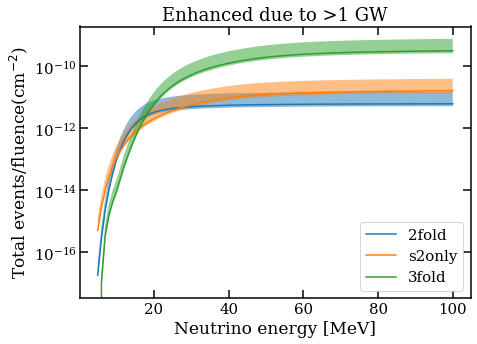

In [116]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
plt.plot(Neutrino_Energy/MeV, stacking(d_2fold)*rate_Ev_2fold, label="2fold")
plt.fill_between(Neutrino_Energy/MeV, stacking(d_2fold)*rate_Ev_2fold*modification_low, stacking(d_2fold)*rate_Ev_2fold*modification_up, alpha = 0.5)

plt.plot(Neutrino_Energy/MeV, stacking(d_S2only)*rate_Ev_S2only, label="s2only")
plt.fill_between(Neutrino_Energy/MeV, stacking(d_S2only)*rate_Ev_S2only*modification_low, stacking(d_S2only)*rate_Ev_S2only*modification_up, alpha = 0.5)

plt.plot(Neutrino_Energy/MeV, stacking(d_3fold)*rate_Ev_3fold, label="3fold")
plt.fill_between(Neutrino_Energy/MeV, stacking(d_3fold)*rate_Ev_3fold*modification_low, stacking(d_3fold)*rate_Ev_3fold*modification_up, alpha = 0.5)

#ax.legend()
ax.set_title("Enhanced due to >1 GW")
#ax.set_ylim([1e-2, 1e2])
#ax.set_xlim([0, 5])
plt.yscale("log")

ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Total events/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.legend()
plt.show()

In [119]:
upper_lim_fluence_2_fold = 2.3/(rate_Ev_2fold*stacking(d_2fold))
upper_lim_fluence_2_fold_low = 2.3/(rate_Ev_2fold*modification_low*stacking(d_2fold))
upper_lim_fluence_2_fold_up = 2.3/(rate_Ev_2fold*modification_up*stacking(d_2fold))

upper_lim_fluence_3_fold = 2.3/(rate_Ev_3fold*stacking(d_3fold))
upper_lim_fluence_3_fold_low = 2.3/(rate_Ev_3fold*modification_low*stacking(d_3fold))
upper_lim_fluence_3_fold_up = 2.3/(rate_Ev_3fold*modification_up*stacking(d_3fold))

upper_lim_fluence_S2only = 2.3/(rate_Ev_S2only*stacking(d_S2only))
upper_lim_fluence_S2only_low = 2.3/(rate_Ev_S2only*modification_low*stacking(d_S2only))
upper_lim_fluence_S2only_up = 2.3/(rate_Ev_S2only*modification_up*stacking(d_S2only))

<ipython-input-119-86906107e7a7>:5: RuntimeWarning: divide by zero encountered in true_divide
  upper_lim_fluence_3_fold = 2.3/(rate_Ev_3fold*stacking(d_3fold))
<ipython-input-119-86906107e7a7>:6: RuntimeWarning: divide by zero encountered in true_divide
  upper_lim_fluence_3_fold_low = 2.3/(rate_Ev_3fold*modification_low*stacking(d_3fold))
<ipython-input-119-86906107e7a7>:7: RuntimeWarning: divide by zero encountered in true_divide
  upper_lim_fluence_3_fold_up = 2.3/(rate_Ev_3fold*modification_up*stacking(d_3fold))


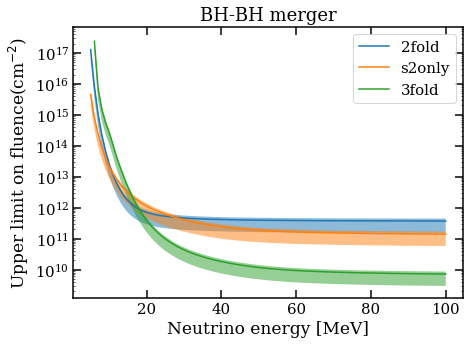

In [120]:

fig, ax = plt.subplots(1, 1, figsize=(7,5))
plt.plot(Neutrino_Energy/MeV, upper_lim_fluence_2_fold, label="2fold")
plt.fill_between(Neutrino_Energy/MeV, upper_lim_fluence_2_fold_low, upper_lim_fluence_2_fold_up, alpha = 0.5)

plt.plot(Neutrino_Energy/MeV, upper_lim_fluence_S2only, label="s2only")
plt.fill_between(Neutrino_Energy/MeV, upper_lim_fluence_S2only_low, upper_lim_fluence_S2only_up, alpha = 0.5)

plt.plot(Neutrino_Energy/MeV, upper_lim_fluence_3_fold, label="3fold")
plt.fill_between(Neutrino_Energy/MeV, upper_lim_fluence_3_fold_low, upper_lim_fluence_3_fold_up, alpha = 0.5)

ax.legend()
#ax.set_title(r"(Total events/flux ")
#ax.set_ylim([1e6, 1e16])
plt.yscale("log")
#ax.set_xlim([0, 5])
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"Upper limit on fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.title("BH-BH merger")

plt.show()

For 30 Gev/c^2 dark matter limits on dark matter cross-section (in cm^2):

3-fold -> 4.5 * 10^-46

S2-only -> 4.5 * 10^-45

i.e. an order magnitude worse. Matches with our limits.

# Sanity Checks - 80 MeV Neutrinos

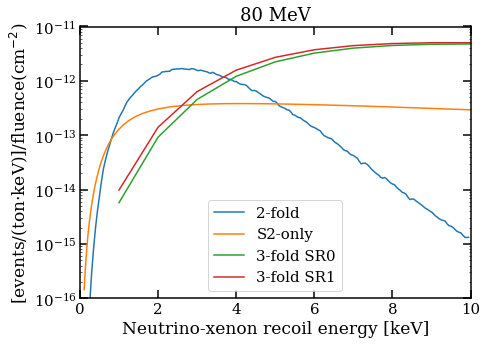

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))


er = []
for i in range(0,np.shape(energy_2fold)[0]-1):
    er.append((energy_2fold[i]+energy_2fold[i+1])/2)
er=np.array(er)
tot_rate = np.array([sum([xe.dRatedErecoil(x, 80*MeV) for xe in NaturalXe]) * accept_2fold(x) for x in er])
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="2-fold")


er = []
for i in range(0,np.shape(energy_S2only)[0]-1):
    er.append((energy_S2only[i]+energy_S2only[i+1])/2)
er=np.array(er)
tot_rate = np.array([sum([xe.dRatedErecoil(x, 80*MeV) for xe in NaturalXe]) * accept_S2only(x) for x in er])
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="S2-only")

er = []
for i in range(0,np.shape(energy_3fold)[0]-1):
    er.append((energy_3fold[i]+energy_3fold[i+1])/2)
er=np.array(er)

tot_rate = np.array([sum([xe.dRatedErecoil(x, 80*MeV) for xe in NaturalXe]) * accept_3fold_SR0(x) for x in er])
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="3-fold SR0")

tot_rate = np.array([sum([xe.dRatedErecoil(x, 80*MeV) for xe in NaturalXe]) * accept_3fold_SR1(x) for x in er])
ax.semilogy(er / keV, tot_rate / (keV**(-1) * ton**(-1)), label="3-fold SR1")

ax.legend()
ax.set_title(r"80 MeV")
ax.set_ylim([1e-16, 1e-11])
ax.set_xlim([0, 10])
ax.set_xlabel("Neutrino-xenon recoil energy [keV]")
ax.set_ylabel(r"[events/(ton$\cdot$keV)]/fluence(cm$^{-2}$)")
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')

plt.show()

In [36]:
total_rate = 0
for i in range(0,np.shape(energy_S2only)[0]-1):
    er = (energy_S2only[i]+energy_S2only[i+1])/2
    delta_energy = energy_S2only[i+1] - energy_S2only[i]
    rate = sum([xe.dRatedErecoil(er, 80*MeV) for xe in NaturalXe]) * accept_S2only(er)
    total_rate = total_rate + rate * delta_energy * 2.004 * ton
total_rate

1.2390942667886128e-11

In [37]:
total_rate = 0
for i in range(0,np.shape(energy_2fold)[0]-1):
    er = (energy_2fold[i]+energy_2fold[i+1])/2
    delta_energy = energy_2fold[i+1] - energy_2fold[i]
    rate = sum([xe.dRatedErecoil(er, 80*MeV) for xe in NaturalXe]) * accept_2fold(er)
    total_rate = total_rate + rate * delta_energy * 1.04 * ton
total_rate

4.85843435610784e-12

In [38]:
total_rate = 0

for i in range(0,np.shape(energy_3fold)[0]-1):
    er=((energy_3fold[i]+energy_3fold[i+1])/2)
    delta_energy = energy_3fold[i+1] - energy_3fold[i]
    rate = sum([xe.dRatedErecoil(er, 80*MeV) for xe in NaturalXe]) * accept_3fold_SR1(er)
    total_rate = total_rate + rate * delta_energy * 1.3 * ton
total_rate

1.3156777279577983e-10

# Axion limits

In [42]:
N_T

4.588020143230578e+27

In [43]:
efficiency_ER = 0.89 #figure 2 of https://arxiv.org/pdf/2006.09721.pdf

In [44]:
Cross_section = 10**(-28) #cm^2 #XENONnT limit for 10 keV ALPs https://arxiv.org/pdf/2207.11330.pdf

In [45]:
N_T * efficiency_ER * Cross_section

0.4083337927475214

In [49]:
UL_fluence = 2.3/(N_T * efficiency_ER * Cross_section)
UL_fluence

5.632646723956356

In [47]:
Mpc = 3.0857*10**22 #m
distance_merger = 40 * Mpc #m #for GW170817

In [50]:
UL_fluence * (4*3.14*distance_merger**2)

1.0777785512244096e+50